# LeNet-5 — Early Convolutional Networks and PyTorch Implementation

## Overview

This notebook implements LeNet-5 from first principles in PyTorch. The central architectural idea is local receptive fields, parameter sharing, average-pooling subsampling, and a compact convolution-to-classifier hierarchy. The implementation uses MNIST with 10 handwritten digit classes, and the notebook demonstrates the data pipeline, model construction, inspection, training, evaluation, and prediction workflow.


## Table of Contents

- [Overview](#overview)
- [Learning Objectives](#learning-objectives)
- [Architecture Theory](#architecture-theory)
- [Environment Setup](#environment-setup)
- [Configuration](#configuration)
- [Reproducibility](#reproducibility)
- [Device Selection](#device-selection)
- [Data Augmentation and Preprocessing](#data-augmentation-and-preprocessing)
- [Dataset Construction and Splitting](#dataset-construction-and-splitting)
- [Data Loaders](#data-loaders)
- [Dataset Inspection](#dataset-inspection)
- [Complete Model](#complete-model)
- [Model Initialization](#model-initialization)
- [Model Inspection](#model-inspection)
- [Parameter Count](#parameter-count)
- [Training Objective and Optimizer](#training-objective-and-optimizer)
- [Training Function](#training-function)
- [Evaluation Function](#evaluation-function)
- [Training Loop](#training-loop)
- [Test Evaluation](#test-evaluation)
- [Training History Visualization](#training-history-visualization)
- [Prediction Visualization](#prediction-visualization)
- [Key Takeaways](#key-takeaways)


## Learning Objectives

By the end of this notebook, we should understand:

- why local connectivity and parameter sharing make convolutional networks efficient for images.
- how padding converts MNIST images from 28 x 28 to the 32 x 32 input expected by this implementation.
- how convolution and average pooling progressively transform tensor shapes.
- where this PyTorch implementation differs from historical LeNet-5, especially the use of ReLU.
- how the model is trained, evaluated, and inspected on MNIST.


## Architecture Theory

LeNet-5 established the early convolutional pattern for visual recognition: spatial filters extract local features, pooling reduces resolution, and a small classifier maps the learned representation to class logits. The architecture relies on parameter sharing, so a single kernel is applied across all spatial locations instead of learning a separate parameter for every pixel position.

Historical LeNet-5 used sigmoid or tanh-like nonlinearities and partially connected convolutional maps. This repository implements a modernized PyTorch version: it uses full convolutions, ReLU activations, average pooling, and raw logits for `CrossEntropyLoss`. The important architectural idea remains the same: features become increasingly abstract as spatial resolution decreases.

| Stage | Operation | Output Shape |
| --- | --- | --- |
| Input | padded MNIST image | `(N, 1, 32, 32)` |
| C1 | `5 x 5` convolution, `1 -> 6` | `(N, 6, 28, 28)` |
| S2 | `2 x 2` average pooling | `(N, 6, 14, 14)` |
| C3 | `5 x 5` convolution, `6 -> 16` | `(N, 16, 10, 10)` |
| S4 | `2 x 2` average pooling | `(N, 16, 5, 5)` |
| C5 | `5 x 5` convolution, `16 -> 120` | `(N, 120, 1, 1)` |
| F6 | linear layer | `(N, 84)` |
| Output | linear classifier | `(N, 10)` |


## Environment Setup

The notebook uses PyTorch for tensor computation and neural network modules, torchvision for datasets and transforms, NumPy and Python randomness for reproducibility, and Matplotlib for visualization.


In [1]:
from __future__ import annotations

import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms


## Configuration

The following constants define the experiment. They are kept from the source script so the notebook remains traceable to the original implementation.


In [2]:
DATA_DIRECTORY = "./data"
BATCH_SIZE = 64
LEARNING_RATE = 0.001
NUM_EPOCHS = 30
VALIDATION_SIZE = 5_000
RANDOM_SEED = 42
NUMBER_OF_WORKERS = 4


## Reproducibility

Random seeds make dataset splitting, parameter initialization, and stochastic operations easier to reproduce across runs. Exact determinism can still depend on hardware kernels and backend behavior.


In [3]:
def set_seed(seed: int) -> None:
    """Set the random seed for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_SEED)


## Device Selection

The model is moved to the best available device. CUDA is preferred when available, followed by Apple MPS, and then CPU.


In [4]:
def get_device() -> torch.device:
    "Return the best available device (GPU if available, else CPU)."
    if torch.cuda.is_available():
        return torch.device("cuda")

    if torch.backends.mps.is_available():
        return torch.device("mps")

    return torch.device("cpu")

device = get_device()
print(f"Using device: {device}")


Using device: cpu


## Data Augmentation and Preprocessing

MNIST images are padded from `28 x 28` to `32 x 32`, converted to tensors, and normalized. Padding preserves the LeNet-style tensor flow used by the implementation.


In [5]:
mnist_transform = transforms.Compose([
    # Original MNIST images:
    # (1, 28, 28)
    # After padding:
    # (1, 32, 32)
    transforms.Pad(padding=2),

    # Convert PIL image to tensor
    # Change from (H, W, C) to (C, H, W)
    # Pixel range changes from [0, 255] to [0.0, 1.0]
    transforms.ToTensor(),

    # Normalize approximately from [0.0, 1.0] to [-1.0, 1.0]
    transforms.Normalize((0.5,), (0.5,)),
])


## Dataset Construction and Splitting

The dataset objects define the supervised image-classification task and its train, validation, and test usage. The source implementation creates validation data from the training split and reserves the official evaluation split for final testing where applicable.


In [6]:
full_training_dataset = datasets.MNIST(
    root=DATA_DIRECTORY,
    train=True,
    transform=mnist_transform,
    download=True
)

test_dataset = datasets.MNIST(
    root=DATA_DIRECTORY,
    train=False,
    transform=mnist_transform,
    download=True
)

training_size = len(full_training_dataset) - VALIDATION_SIZE
split_generator = torch.Generator().manual_seed(RANDOM_SEED)

training_dataset, validation_dataset = random_split(
    dataset=full_training_dataset,
    lengths=[training_size, VALIDATION_SIZE],
    generator=split_generator
)

print(f"Training samples: {len(training_dataset)}")
print(f"Validation samples: {len(validation_dataset)}")
print(f"Test samples: {len(test_dataset)}")


Training samples: 55000
Validation samples: 5000
Test samples: 10000


## Data Loaders

Data loaders batch examples, optionally shuffle the training subset, and pin memory when CUDA is used. Validation and test loaders are not shuffled because their order does not affect the metrics.


In [7]:
pin_memory = device.type == "cuda"

training_loader = DataLoader(
    dataset=training_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUMBER_OF_WORKERS,
    pin_memory=pin_memory
)

validation_loader = DataLoader(
    dataset=validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUMBER_OF_WORKERS,
    pin_memory=pin_memory
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUMBER_OF_WORKERS,
    pin_memory=pin_memory
)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## Dataset Inspection

A small batch visualization helps verify that padding, normalization, and labels are wired correctly. The display reverses the MNIST normalization before plotting.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


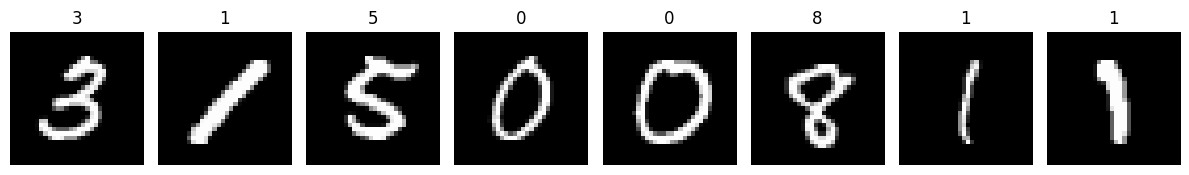

In [8]:
def show_training_examples(data_loader: DataLoader, number_of_images: int = 8) -> None:
    images, labels = next(iter(data_loader))
    images = images[:number_of_images]
    labels = labels[:number_of_images]

    images = images * 0.5 + 0.5
    fig, axes = plt.subplots(1, number_of_images, figsize=(12, 2))

    for axis, image, label in zip(axes, images, labels):
        axis.imshow(image.squeeze(0), cmap="gray")
        axis.set_title(str(int(label)))
        axis.axis("off")

    plt.tight_layout()
    plt.show()

show_training_examples(training_loader)


## Complete Model

The class below implements the complete LeNet-style network. Each convolution or pooling operation corresponds to the tensor-flow table introduced above.


In [9]:
class LeNet5(nn.Module):
    """LeNet-5 style image classification network."""

    def __init__(self, number_of_classes: int = 10) -> None:
        super().__init__()

        # C1: Convolutional layer
        # (N, 1, 32, 32) -> (N, 6, 28, 28)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=0)

        self.relu1 = nn.ReLU()

        # S2: Average pooling layer
        # (N, 6, 28, 28) -> (N, 6, 14, 14)
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)

        # C3: Convolutional layer
        # (N, 6, 14, 14) -> (N, 16, 10, 10)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16,kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU()

        # S4: Average pooling layer
        # (N, 16, 10, 10) -> (N, 16, 5, 5)
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)

        # C5: Convolutional layer
        # (N, 16, 5, 5) -> (N, 120, 1, 1)
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5, stride=1, padding=0)
        self.relu3 = nn.ReLU()

        # Flatten the output for the fully connected layers
        # (N, 120, 1, 1) -> (N, 120)
        self.flatten = nn.Flatten(start_dim=1)

        # F6: Fully connected layer
        # (N, 120) -> (N, 84)
        self.fc1 = nn.Linear(in_features=120, out_features=84)

        self.relu4 = nn.ReLU()

        # Output layer
        # (N, 84) -> (N, number_of_classes)
        self.output_layer = nn.Linear(in_features=84, out_features=number_of_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Input: x of shape (N, 1, 32, 32)
        Output: logits of shape (N, number_of_classes)
        """
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.relu3(x)

        x = self.flatten(x)

        x = self.fc1(x)
        x = self.relu4(x)

        logits = self.output_layer(x)

        return logits


## Model Initialization

The model is instantiated with the configured number of classes and moved to the selected device so parameters and input tensors live on the same backend.


In [10]:
model = LeNet5(number_of_classes=10).to(device)

print("Model architecture:")
print(model)


Model architecture:
LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (relu1): ReLU()
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (relu2): ReLU()
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv3): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (relu3): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=120, out_features=84, bias=True)
  (relu4): ReLU()
  (output_layer): Linear(in_features=84, out_features=10, bias=True)
)


## Model Inspection

Shape inspection is a lightweight sanity check. It verifies that a synthetic input flows through the model and produces logits with the expected class dimension.


In [11]:
def inspect_model_shapes(
    model: LeNet5,
    device: torch.device
) -> None:
    """Print the tensor shape after every major model operation."""
    sample_batch = torch.randn(
        8,
        1,
        32,
        32,
        device=device,
    )

    model.eval()

    with torch.inference_mode():
        print("\nShape inspection:")
        print(f"Input:         {tuple(sample_batch.shape)}")

        x = model.conv1(sample_batch)
        print(f"After C1:      {tuple(x.shape)}")

        x = model.relu1(x)
        print(f"After ReLU 1:  {tuple(x.shape)}")

        x = model.pool1(x)
        print(f"After S2:      {tuple(x.shape)}")

        x = model.conv2(x)
        print(f"After C3:      {tuple(x.shape)}")

        x = model.relu2(x)
        print(f"After ReLU 2:  {tuple(x.shape)}")

        x = model.pool2(x)
        print(f"After S4:      {tuple(x.shape)}")

        x = model.conv3(x)
        print(f"After C5:      {tuple(x.shape)}")

        x = model.relu3(x)
        print(f"After ReLU 3:  {tuple(x.shape)}")

        x = model.flatten(x)
        print(f"After Flatten: {tuple(x.shape)}")

        x = model.fc1(x)
        print(f"After F6:      {tuple(x.shape)}")

        x = model.relu4(x)
        print(f"After ReLU 4:  {tuple(x.shape)}")

        logits = model.output_layer(x)
        print(f"Logits:        {tuple(logits.shape)}")

inspect_model_shapes(model=model, device=device)



Shape inspection:
Input:         (8, 1, 32, 32)
After C1:      (8, 6, 28, 28)
After ReLU 1:  (8, 6, 28, 28)
After S2:      (8, 6, 14, 14)
After C3:      (8, 16, 10, 10)
After ReLU 2:  (8, 16, 10, 10)
After S4:      (8, 16, 5, 5)
After C5:      (8, 120, 1, 1)
After ReLU 3:  (8, 120, 1, 1)
After Flatten: (8, 120)
After F6:      (8, 84)
After ReLU 4:  (8, 84)
Logits:        (8, 10)


## Parameter Count

Parameter count is a rough measure of model capacity and storage cost. It does not fully measure computation, but it helps compare architectural trade-offs.


In [12]:
def count_parameters(model: nn.Module) -> tuple[int, int]:
    """Return total and trainable parameter counts of the model."""

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    return total_params, trainable_params

total_params, trainable_params = count_parameters(model=model)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")



Total parameters: 61,706
Trainable parameters: 61,706


## Training Objective and Optimizer

For multi-class classification, the network outputs logits. `CrossEntropyLoss` combines log-softmax and negative log-likelihood, so the model should not apply softmax before the loss. The optimizer updates trainable parameters according to the configured learning rate.


In [13]:
# CrossEntropyLoss expects:
#
# logits:
#   shape = (N, 10)
#
# labels:
#   shape = (N,)
#   dtype = torch.int64
#
# Do not apply Softmax before CrossEntropyLoss.

loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


## Training Function

One training epoch performs forward propagation, loss computation, gradient reset, backpropagation, optimizer update, and metric accumulation.


In [14]:
def train_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    loss_function: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device
) -> tuple[float, float]:
    """Train model for one epoch"""

    model.train()

    accumulated_loss = 0.0
    number_of_correct_predictions = 0
    number_of_samples = 0

    for images, labels in data_loader:
        images = images.to(
            device,
            non_blocking=device.type == "cuda",
        )

        labels = labels.to(
            device,
            non_blocking=device.type == "cuda",
        )

        # Remove gradients calculated in the previous iteration.
        optimizer.zero_grad(set_to_none=True)

        # Forward pass
        logits = model(images)

        # Compute loss
        loss = loss_function(logits, labels)

        # Backward pass
        loss.backward()

        # Update model parameters
        optimizer.step()

        current_batch_size = images.size(0)

        accumulated_loss += loss.item() * current_batch_size
        number_of_samples += current_batch_size

        predictedions = logits.argmax(dim=1)

        number_of_correct_predictions += (predictedions == labels).sum().item()

    average_loss = accumulated_loss / number_of_samples

    accuracy = number_of_correct_predictions / number_of_samples

    return average_loss, accuracy


## Evaluation Function

Evaluation disables gradient tracking and measures loss and accuracy without updating parameters.


In [15]:
def evaluate(
    model: nn.Module,
    data_loader: DataLoader,
    loss_function: nn.Module,
    device: torch.device
) -> tuple[float, float]:
    """Evaluate model on validation or test dataset"""

    model.eval()

    accumulated_loss = 0.0
    number_of_correct_predictions = 0
    number_of_samples = 0

    with torch.inference_mode():
        for images, labels in data_loader:
            images = images.to(
                device,
                non_blocking=device.type == "cuda",
            )

            labels = labels.to(
                device,
                non_blocking=device.type == "cuda",
            )

            # Forward pass
            logits = model(images)

            # Compute loss
            loss = loss_function(logits, labels)

            current_batch_size = images.size(0)

            accumulated_loss += loss.item() * current_batch_size
            number_of_samples += current_batch_size

            predictedions = logits.argmax(dim=1)

            number_of_correct_predictions += (predictedions == labels).sum().item()

    average_loss = accumulated_loss / number_of_samples

    accuracy = number_of_correct_predictions / number_of_samples

    return average_loss, accuracy


## Training Loop

The training loop coordinates epochs, validation, and history recording. Running the next cell can take a long time because it executes the full configured experiment.


In [16]:
training_loss_history: list[float] = []
validation_loss_history: list[float] = []

training_accuracy_history: list[float] = []
validation_accuracy_history: list[float] = []

for epoch in range(1, NUM_EPOCHS + 1):
    training_loss, training_accuracy = train_one_epoch(
        model=model,
        data_loader=training_loader,
        loss_function=loss_function,
        optimizer=optimizer,
        device=device
    )

    validation_loss, validation_accuracy = evaluate(
        model=model,
        data_loader=validation_loader,
        loss_function=loss_function,
        device=device
    )

    training_loss_history.append(training_loss)
    validation_loss_history.append(validation_loss)

    training_accuracy_history.append(training_accuracy)
    validation_accuracy_history.append(validation_accuracy)

    print(
        f"Epoch [{epoch:02d}/{NUM_EPOCHS:02d}] | "
        f"Training loss: {training_loss:.4f} | "
        f"Training accuracy: {training_accuracy:.2%} | "
        f"Validation loss: {validation_loss:.4f} | "
        f"Validation accuracy: {validation_accuracy:.2%}"
    )


Epoch [01/30] | Training loss: 0.3313 | Training accuracy: 89.88% | Validation loss: 0.1483 | Validation accuracy: 95.60%
Epoch [02/30] | Training loss: 0.1060 | Training accuracy: 96.64% | Validation loss: 0.1101 | Validation accuracy: 96.60%
Epoch [03/30] | Training loss: 0.0730 | Training accuracy: 97.71% | Validation loss: 0.0769 | Validation accuracy: 97.72%
Epoch [04/30] | Training loss: 0.0560 | Training accuracy: 98.28% | Validation loss: 0.0728 | Validation accuracy: 97.78%
Epoch [05/30] | Training loss: 0.0465 | Training accuracy: 98.58% | Validation loss: 0.0559 | Validation accuracy: 98.40%
Epoch [06/30] | Training loss: 0.0381 | Training accuracy: 98.84% | Validation loss: 0.0551 | Validation accuracy: 98.26%
Epoch [07/30] | Training loss: 0.0326 | Training accuracy: 98.96% | Validation loss: 0.0426 | Validation accuracy: 98.68%
Epoch [08/30] | Training loss: 0.0293 | Training accuracy: 99.08% | Validation loss: 0.0429 | Validation accuracy: 98.64%
Epoch [09/30] | Training

## Test Evaluation

The test set is used after training for final evaluation. Training data optimizes parameters, validation data monitors model selection, and test data estimates final generalization.


In [17]:
test_loss, test_accuracy = evaluate(
    model=model,
    data_loader=test_loader,
    loss_function=loss_function,
    device=device
)

print("Test results:")
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")


Test results:
Test loss: 0.0625
Test accuracy: 98.91%


## Training History Visualization

History plots show whether optimization is improving and whether validation behavior diverges from training behavior.


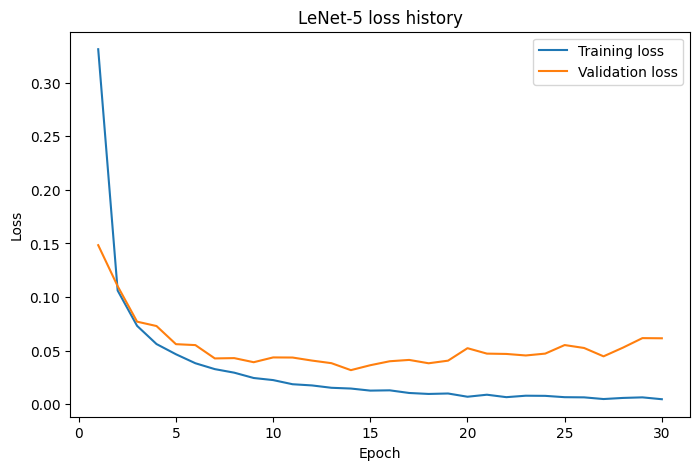

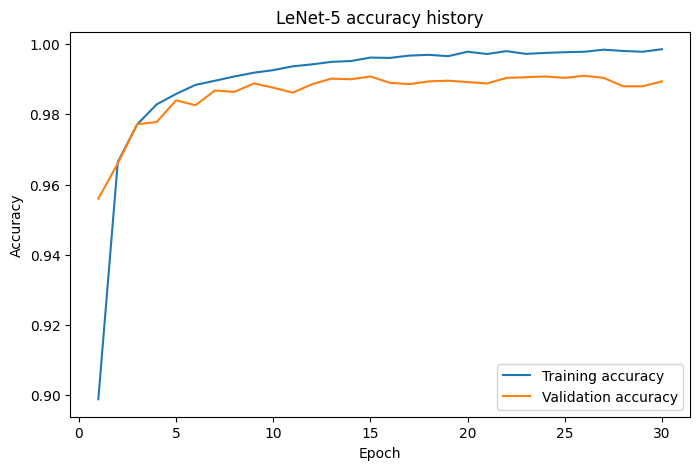

In [18]:
epoch_numbers = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epoch_numbers,
    training_loss_history,
    label="Training loss",
)

plt.plot(
    epoch_numbers,
    validation_loss_history,
    label="Validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LeNet-5 loss history")
plt.legend()
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    epoch_numbers,
    training_accuracy_history,
    label="Training accuracy",
)

plt.plot(
    epoch_numbers,
    validation_accuracy_history,
    label="Validation accuracy",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LeNet-5 accuracy history")
plt.legend()
plt.show()


## Prediction Visualization

Prediction visualization connects logits back to input images, ground-truth labels, and predicted labels. Images are denormalized before display when needed.


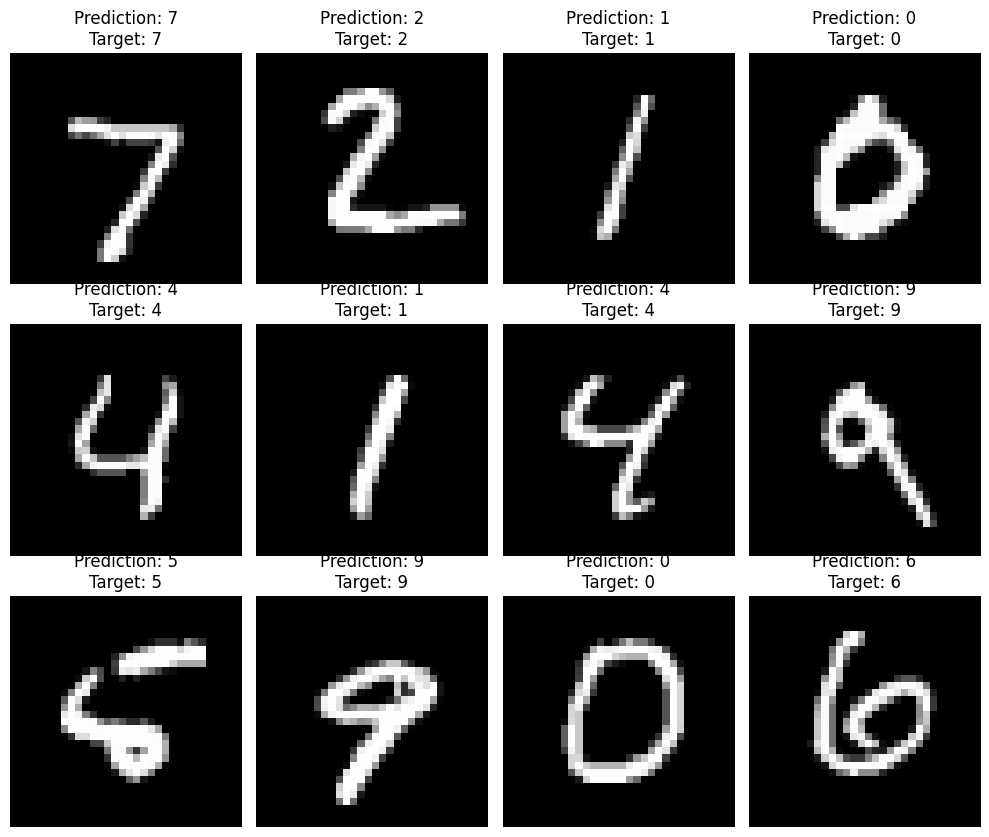

In [19]:
def denormalize_image(image: torch.Tensor) -> torch.Tensor:
    """Reverse Normalize(mean=0.5, std=0.5)."""
    return image * 0.5 + 0.5


def visualize_predictions(
    model: nn.Module,
    data_loader: DataLoader,
    device: torch.device,
    number_of_images: int = 12,
) -> None:
    """Visualize model predictions on one mini-batch."""
    model.eval()

    images, labels = next(iter(data_loader))

    images = images[:number_of_images]
    labels = labels[:number_of_images]

    with torch.inference_mode():
        logits = model(images.to(device))
        predictions = logits.argmax(dim=1).cpu()

    number_of_columns = 4

    number_of_rows = int(
        np.ceil(number_of_images / number_of_columns)
    )

    plt.figure(
        figsize=(10, 2.8 * number_of_rows)
    )

    for image_index in range(number_of_images):
        image = denormalize_image(
            images[image_index]
        )

        plt.subplot(
            number_of_rows,
            number_of_columns,
            image_index + 1,
        )

        plt.imshow(
            image.squeeze(dim=0),
            cmap="gray",
        )

        predicted_label = predictions[
            image_index
        ].item()

        true_label = labels[
            image_index
        ].item()

        plt.title(
            f"Prediction: {predicted_label}\n"
            f"Target: {true_label}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()


visualize_predictions(
    model=model,
    data_loader=test_loader,
    device=device,
)


## Key Takeaways

- LeNet-5 demonstrates the basic CNN pattern of convolution, nonlinearity, subsampling, and classification.
- Padding MNIST to 32 x 32 makes the tensor flow match the classical LeNet spatial progression.
- This implementation is LeNet-like but modernized with ReLU activations and full convolutional connectivity.
